In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = (
    project_root
    / "data"
    / "processed"
    / "nhanes_2017_2018_enriched.csv"
)

data = pd.read_csv(data_path)

# Keep participants without confirmed diabetes.
data = data[
    data["diabetes_diagnosis_code"].isin([2, 3])
].copy()

print("Screening population shape:", data.shape)

print("\nTarget percentages:")
print(
    data["elevated_a1c"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Screening population shape: (4451, 18)

Target percentages:
elevated_a1c
0    65.15
1    34.85
Name: proportion, dtype: float64


In [2]:
baseline_numeric_features = [
    "age",
    "bmi",
    "waist_cm"
]

baseline_categorical_features = [
    "sex_code",
    "race_ethnicity_code"
]

enriched_numeric_features = [
    "age",
    "bmi",
    "waist_cm",
    "avg_systolic_bp",
    "avg_diastolic_bp",
    "recreation_met_minutes_week",
    "sedentary_minutes",
    "average_sleep_hours"
]

enriched_categorical_features = [
    "sex_code",
    "race_ethnicity_code",
    "smoking_status"
]

baseline_features = (
    baseline_numeric_features
    + baseline_categorical_features
)

enriched_features = (
    enriched_numeric_features
    + enriched_categorical_features
)

target = data["elevated_a1c"]

train_indices, test_indices = train_test_split(
    data.index,
    test_size=0.20,
    random_state=42,
    stratify=target
)

y_train = target.loc[train_indices]
y_test = target.loc[test_indices]

print("Training rows:", len(train_indices))
print("Testing rows:", len(test_indices))

Training rows: 3560
Testing rows: 891


In [3]:
def create_model(numeric_features, categorical_features):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore")
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(max_iter=1000)
            )
        ]
    )


baseline_model = create_model(
    baseline_numeric_features,
    baseline_categorical_features
)

enriched_model = create_model(
    enriched_numeric_features,
    enriched_categorical_features
)

baseline_model.fit(
    data.loc[train_indices, baseline_features],
    y_train
)

enriched_model.fit(
    data.loc[train_indices, enriched_features],
    y_train
)

print("Both models trained successfully.")

Both models trained successfully.


In [4]:
def evaluate_model(name, model, features):
    X_test = data.loc[test_indices, features]

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions),
        "roc_auc": roc_auc_score(y_test, probabilities)
    }

    return metrics, predictions


baseline_metrics, baseline_predictions = evaluate_model(
    "Baseline",
    baseline_model,
    baseline_features
)

enriched_metrics, enriched_predictions = evaluate_model(
    "Enriched",
    enriched_model,
    enriched_features
)

results = pd.DataFrame(
    [baseline_metrics, enriched_metrics]
).set_index("model")

results.round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline,0.691,0.572,0.448,0.503,0.754
Enriched,0.706,0.600,0.465,0.524,0.753


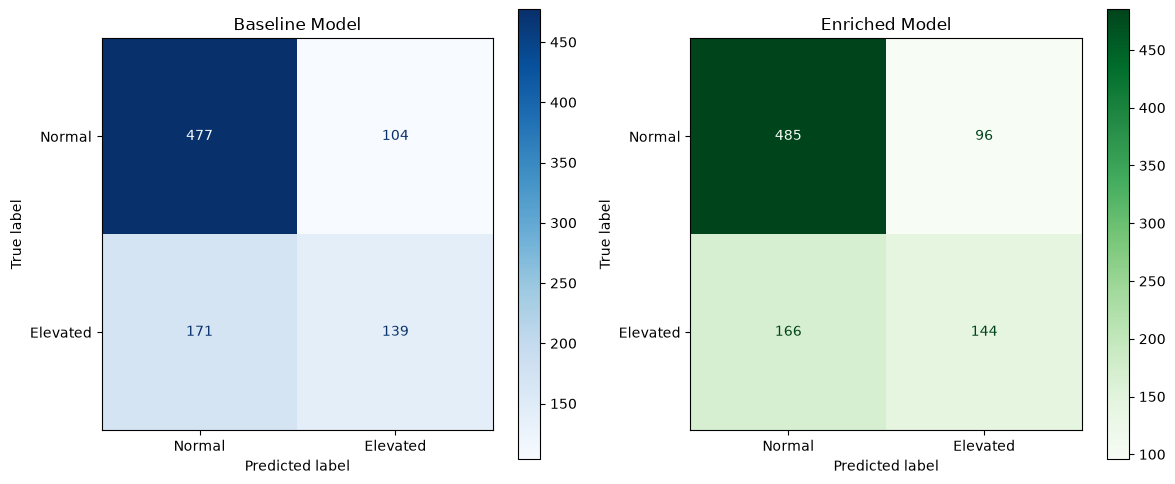

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_predictions,
    display_labels=["Normal", "Elevated"],
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Baseline Model")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    enriched_predictions,
    display_labels=["Normal", "Elevated"],
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("Enriched Model")

plt.tight_layout()
plt.show()